# Research Notebook Week 2
## Ferdinand Soong

# 1: Experience

The goal of this week was to use the Hernquist profile to calculate the gas density of different galaxies. 
## Motivation:

Using the before mentioned ODE we can solve for the gas density $\rho_{gas}$. This can then be transformed into the projected gas density along the line of sight, which can be compared with the observational data from the Gastadello paper.
\begin{equation}
    \frac{dP_{gas}}{dr}=-\frac{GM_{tot}(r)\rho_{gas}(r)}{r^2}
\end{equation}
\begin{equation}
    \frac{d\rho_{gas}}{dr} \cdot \frac{1}{\rho_{gas}}+\frac{dT_{gas}}{dr} \cdot \frac{1}{T_{gas}(r)}=-\frac{GM_{tot}(r)m_{gas}}{k_B T_{gas}(r)r^2}
\end{equation}

# 2: What? (What happened?)
## Describe what happened during your activities for the week.
We adopt the Hernquist profile to get $\phi_b$:
\begin{equation}
    M(r)=M \frac{r^2}{(r+a)^2}
\end{equation}
# code 
import numpy as np
import pandas as pd
import jeans 

G = 4.302e-6   # kpc (km/s)^2 / Msun
Upsilon = 0.8     # Mass-to-light ratio in K-band (Msun/Lsun)

data = {
    "Galaxy": ["NGC720", "NGC1407", "NGC4125", "NGC4261",
               "NGC4472", "NGC4649", "NGC6482"],

    # K-band luminosity (10^11 Lsun)
    "L_K": [1.7, 3.1, 1.8, 2.2, 3.2, 2.5, 3.2],

    #B-band luminosity (10^10 Lsun)
    "L_B": [3.1, 6.4, 4.7, 4.4, 7.5, 5.1, 10.9],
    
    # Effective radius (kpc)
    "R_eff": [3.1, 4.4, 3.3, 3.4, 4.0, 3.2, 3.4]
}

df = pd.DataFrame(data)

df["M_starK"] = Upsilon * df["L_K"] * 1e11


df["M_starB"] = Upsilon * df["L_B"] * 1e10


df["a"] = df["R_eff"] / (1.8153)

df["Phi_ReK"] = -G * df["M_starK"] / (df["R_eff"] + df["a"])

df["Phi_ReB"] = -G * df["M_starB"] / (df["R_eff"] + df["a"])


#df["V_eq"] = np.sqrt(np.abs(df["Phi_Re"]))



pd.set_option("display.float_format", "{:.3e}".format)

print(df)
import matplotlib.pyplot as plt

def stellar_mass(L, band="K"):
    if band=="K":
        return 0.8 * L * 1e11
    else:
        return 0.8 * L * 1e10

def scale_radius(Re):
    return Re / 1.8153

def hernquist_potential(r, M, a):
    return -G * M / (r + a)


r = np.linspace(0.1, 50, 400)


phi_K = {}
phi_B = {}

for row in df.itertuples():

    name = row.Galaxy
    a = row.a

    # K-band
    M_K = row.M_starK
    phi_K[name] = hernquist_potential(r, M_K, a)

    # B-band
    M_B = row.M_starB
    phi_B[name] = hernquist_potential(r, M_B, a)
    
# Using the calculated phi we can use it in the jeans model to create the dm profile(density) example galaxy NGC720
rm = 10.0 # kpc
M200 = 1e12 # Msun
c = 10.0 # dimensionless
q0 = 0.6
AC_inputs = {'AC_prescription': 'Cautun'}

 #Galaxy       L_K       L_B     R_eff   M_starK   M_starB         
 #NGC720 1.700e+00 3.100e+00 3.100e+00 1.360e+11 2.480e+10 1.708e+00   

a=1.708
M_starK=1.480e+11
M_starB=2.480e+10
def Phi_b(r):
    return -G * M_starB / (r + a)



spherical jeans profile with NFW out halo 
profile_spherical = jeans.spherical(rm, M200, c, Phi_b=Phi_b, **AC_inputs)

squashed profile
profile_squashed = jeans.squashed(rm, M200, c, q0=q0, Phi_b=Phi_b, **AC_inputs)

cdm profile
profile_cdm = jeans.cdm(M200, c, q0=q0, Phi_b=Phi_b, **AC_inputs) 

squashed profile
profile_squashed = jeans.squashed(rm, M200, c, q0=q0, Phi_b=Phi_b, **AC_inputs)

cdm profile
profile_cdm = jeans.cdm(M200, c, q0=q0, Phi_b=Phi_b, **AC_inputs) 

# B- and K-Band data
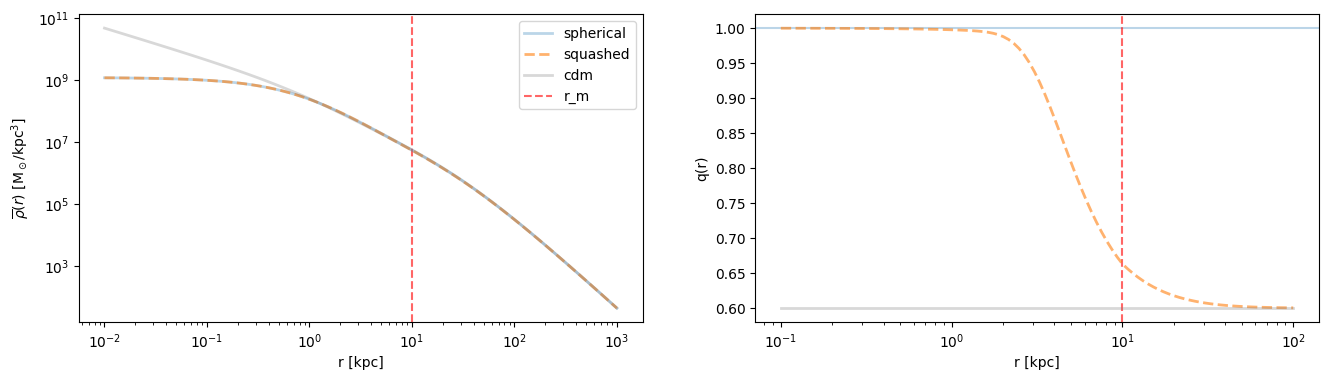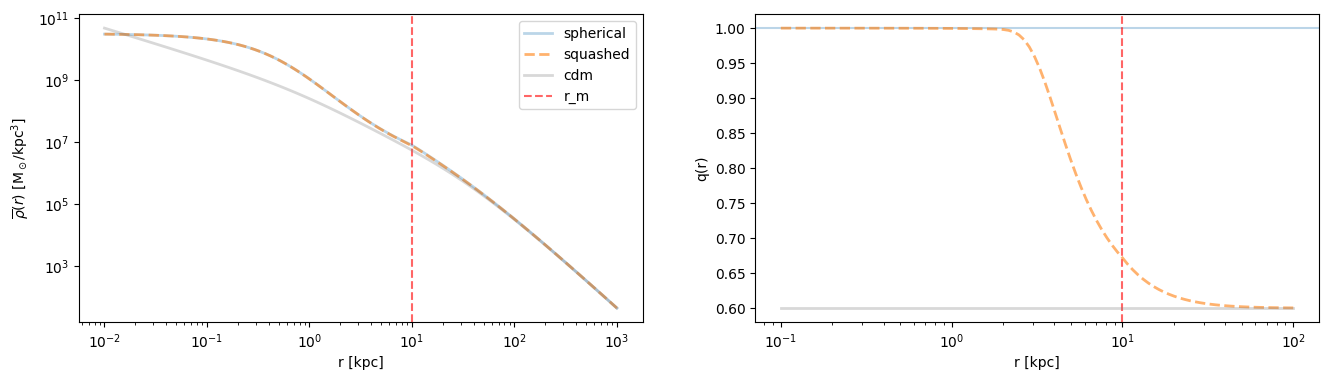

# Using this we calculate the mass and solve the ODE for the gas density
from scipy.integrate import solve_ivp
#drho_g/dr = -rho_g * G * m_g * M_totB / (k_B * T(r) * r**2)  -rho_g/T * dT/dr 
mu=0.6
m_p=1.6726219259552e-27 / (1.989e30) #in Msun
m_g=m_p * mu


def dT_dr(r, dr=1e-3, *args):
    """
    Numerical derivative of T_eq6 with respect to r.
    r : radius in kpc
    dr: small step in kpc
    *args: the other parameters of T_eq6
    """
    return (T_eq6(r + dr, *args) - T_eq6(r - dr, *args)) / (2 * dr)


def T(r, *args):
    return T_eq6(r, *args)


r0 = 1    # starting radius in kpc
rho0 = 1e6    # density at  Msun/kpc^3, d

def drho_dr(r, rho, M_func, *T_params):
    """
    r      : radius
    rho    : gas density
    M_func : function, e.g., M_totB
    *T_params : parameters for T_eq6
    """
    T_r = T_eq6(r, *T_params)
    
    # numerical derivative
    dT_r = (T_eq6(r+1e-3, *T_params) - T_eq6(r-1e-3, *T_params)) / (2*1e-3)
    
    term1 = - m_g * G * M_func(r) / (T_r * r**2)
    term2 = - dT_r / T_r
    
    return rho * (term1 + term2)

solK = solve_ivp(
    lambda r, rho: drho_dr(r, rho, M_totK, a, T1, r1, p1, b, T2, r2, p2, rp, gamma),
    (r0, 200),
    [rho0],
    t_eval=r_eval
)
solB = solve_ivp(
    lambda r, rho: drho_dr(r, rho, M_totB, a, T1, r1, p1, b, T2, r2, p2, rp, gamma),
    (r0, 200),
    [rho0],
    t_eval=r_eval
)

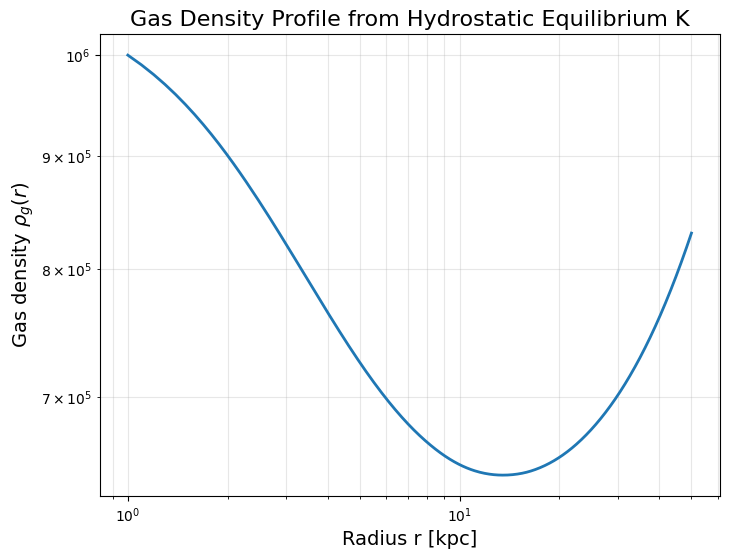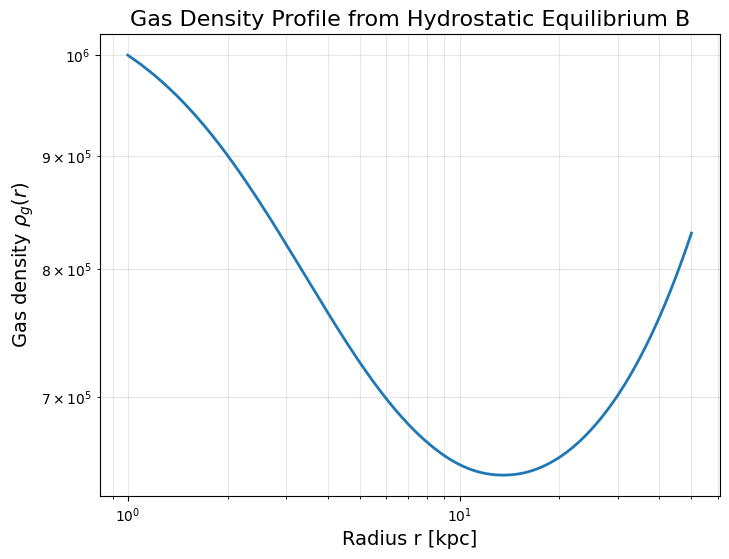




# 3: So what? (What does it mean?)
## Describe your results

These results are not very realistic due to the gas density rising again after 10kpc. This issue is due to setting bad variables for M200(dark matter mass) or other values like rho0 (starting density). The mentioned issue can be solved by increasing M200 by 10, which is also a more realistic value for the dark matter mass of the example galaxy NGC720. 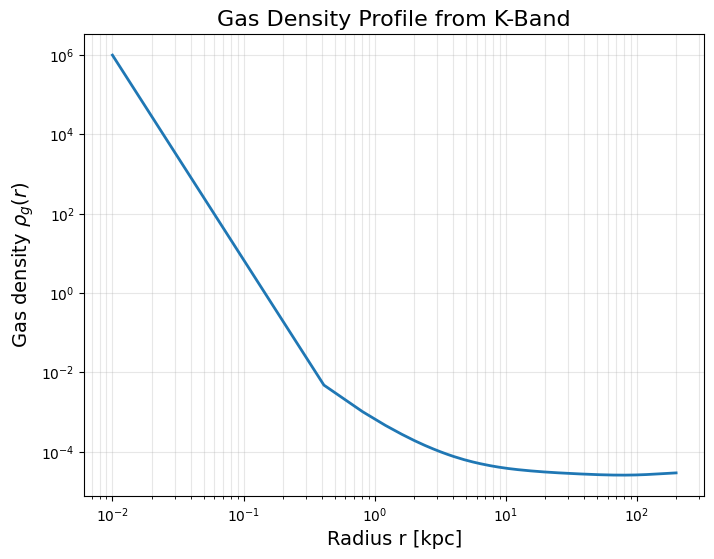
Calculating the squashed profile is obsolete since we only look at a spherical approximation and should be removed.

# 4. Now what? (What's next?)
## Plan for the next week

The next step will be to choose either the K-Band or B-Band data and create a class out of these results to use for MCMC simulations. These will be used to obtain the best values for our variables M200, rho0, Upsilon, rm and c, which then can be compared with the observed data and literature(expected) values of the variabels.

# 5. Bibliography

MAPPING THE DARK MATTER IN THE NGC 5044 GROUP WITH ROSAT: EVIDENCE FOR A NEARLY HOMOGENEOUS COOLING FLOW WITH A COOLING WAKE
LAURENCE P. DAVID, CHRISTINE JONES, AND WILLIAM FORMAN

AN ANALYTICAL MODEL FOR SPHERICAL GALAXIES AND BULGES
Lars Hernquist

PROBING THE DARK MATTER AND GAS FRACTION IN RELAXED GALAXY GROUPS WITH X-RAY
OBSERVATIONS FROM Chandra AND XMM
Fabio Gastaldello1 et al.